# Drop Alert
## The Student Dropout Early Warning System



In [2]:
# Import Libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Import Dataset
df = pd.read_csv('student_performance.csv')
df.head()

,Student_ID,Attendance_%,CGPA,Assignments_Submitted,Lab_Hours_Per_Week,Has_Part_Time_Job,Scholarship,Counsellor_Visits,Dropped_Out
0,STU0672,82.3,7.18,27,8.2,1,1,1,0
1,STU0275,60.0,5.92,29,16.2,0,0,1,1
2,STU1683,87.5,5.23,5,1.2,0,0,4,0
3,STU0663,81.4,6.44,23,10.0,1,0,1,0
4,STU0641,67.4,NaN,12,8.8,0,1,2,1


**Dataset Structure**

In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\n")
df.info()

Shape: (2040, 9)

Columns:
 Index(['Student_ID', 'Attendance_%', 'CGPA', 'Assignments_Submitted',
       'Lab_Hours_Per_Week', 'Has_Part_Time_Job', 'Scholarship',
       'Counsellor_Visits', 'Dropped_Out'],
      dtype='object')

Data Types:
 Student_ID                object
Attendance_%             float64
CGPA                     float64
Assignments_Submitted      int64
Lab_Hours_Per_Week       float64
Has_Part_Time_Job         object
Scholarship                int64
Counsellor_Visits          int64
Dropped_Out                int64
dtype: object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             2040 non-null   object 
 1   Attendance_%           1942 non-null   float64
 2   CGPA                   1940 non-null   float64
 3   Assignments_Submitted  2040 non-null   int64  
 4   Lab_Hours_Per_Week   

In [4]:
#Stats of data
df.describe()

,Attendance_%,CGPA,Assignments_Submitted,Lab_Hours_Per_Week,Scholarship,Counsellor_Visits,Dropped_Out
count,1942.000000,1940.000000,2040.000000,2040.000000,2040.000000,2040.000000,2040.000000
mean,72.217971,6.842371,14.828922,8.030392,0.307353,1.219118,0.358824
std,14.785443,1.344828,8.906998,3.001507,0.461510,1.280834,0.479773
min,20.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,62.600000,5.970000,7.000000,6.000000,0.000000,0.000000,0.000000
50%,71.600000,6.800000,15.000000,8.000000,0.000000,1.000000,0.000000
75%,81.900000,7.602500,23.000000,10.100000,1.000000,2.000000,1.000000
max,113.800000,12.970000,30.000000,18.100000,1.000000,4.000000,1.000000


**Data Cleaning**

In [5]:
# Null values
df.isnull().sum()

,0
Student_ID,0
Attendance_%,98
CGPA,100
Assignments_Submitted,0
Lab_Hours_Per_Week,0
Has_Part_Time_Job,0
Scholarship,0
Counsellor_Visits,0
Dropped_Out,0


In [6]:
# Duplicate records
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 38


In [7]:
# Handle missing values
df.ffill(inplace=True)

In [8]:
# To remove duplicates
df.drop_duplicates(inplace=True)

In [9]:
# Encode categorical values
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

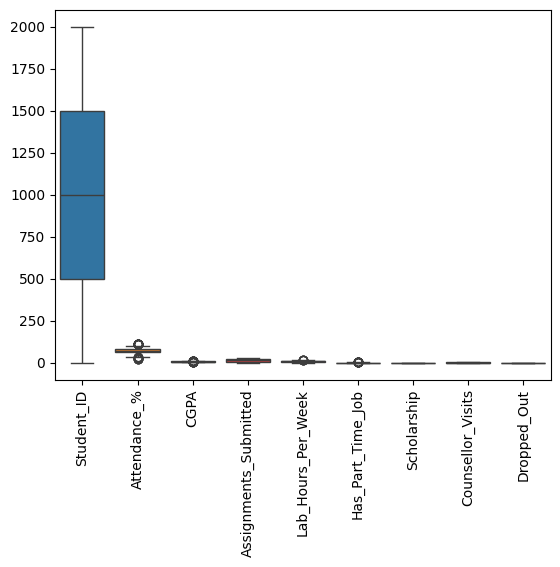

In [10]:
# Check Outliers
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


In [ ]:
# Drop irrelevant columns
df = df.drop(columns=['Student_ID'])

In [12]:
# Separate numerical columns
num_cols = ['Attendance_%', 'CGPA', 'Assignments_Submitted', 'Lab_Hours_Per_Week']

In [13]:
# IQR to handle outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

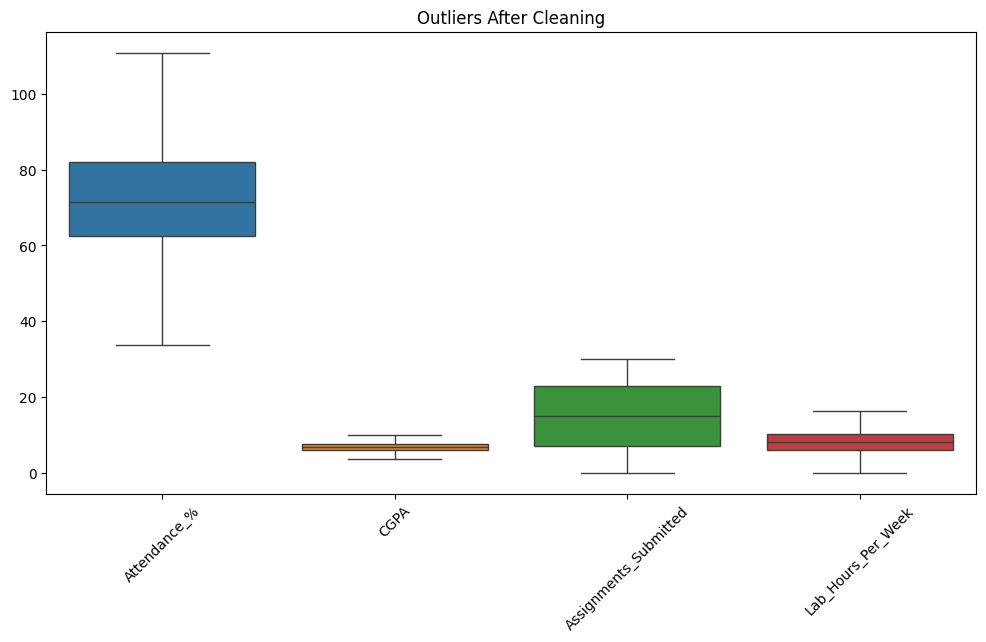

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Outliers After Cleaning")
plt.show()

**EDA**

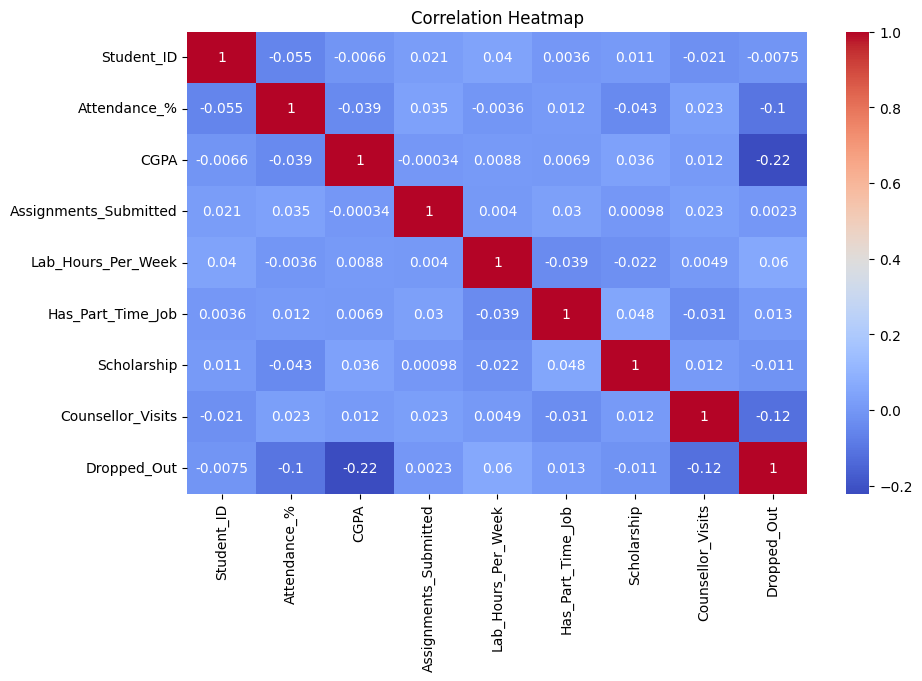

In [15]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Key Feature Analysis**

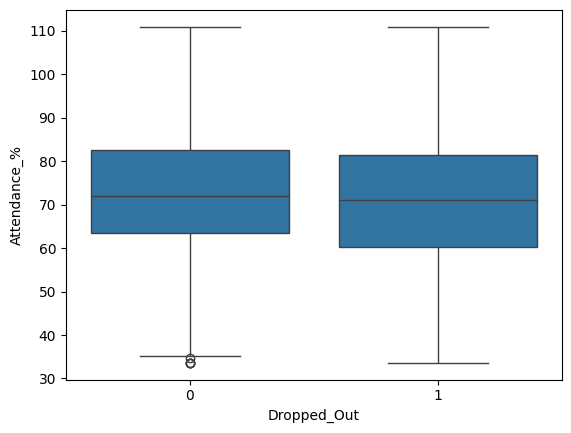

In [16]:
# Attendance vs. Dropout
sns.boxplot(x='Dropped_Out', y='Attendance_%', data=df)
plt.show()

Insight: Attendance shows a clear pattern where students with lower attendance are more likely to drop out.

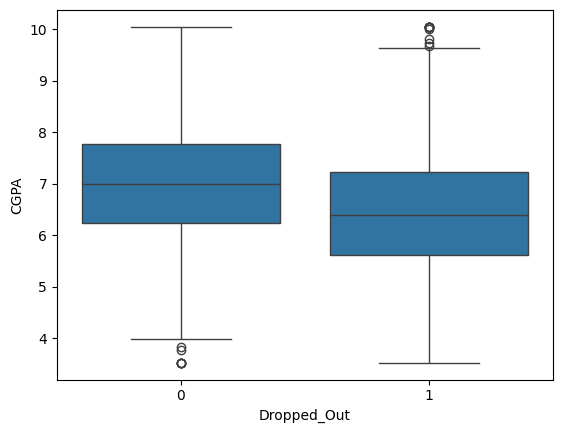

In [17]:
# CGPA vs. Dropout
sns.boxplot(x='Dropped_Out', y='CGPA', data=df)
plt.show()

Insight: Students who dropped out tend to have lower CGPA compared to those who continued. This indicates that academic performance is a strong predictor of student dropout.

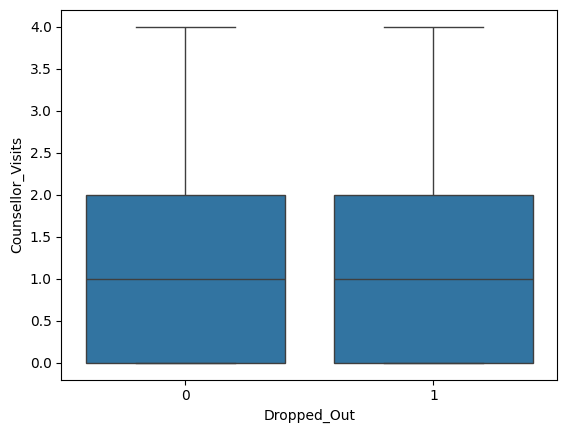

In [18]:
# Counsellor Visits vs. Dropout
sns.boxplot(x='Dropped_Out', y='Counsellor_Visits', data=df)
plt.show()

Insight: Counsellor visits do not show a significant difference between students who dropped out and those who did not, indicating a weak relationship with dropout.




Observations:
1. Students with lower CGPA are more likely to drop out.

2. Lower attendance is associated with higher dropout risk.

3. Counsellor visits show little impact on dropout.

**Feature Engineering**

In [21]:
# Important features
features = ['CGPA', 'Attendance_%', 'Assignments_Submitted',
            'Lab_Hours_Per_Week', 'Counsellor_Visits']

# Target
X = df[features]
y = df['Dropped_Out']

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model Building**

In [22]:
# Train Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Evaluation**

In [23]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.7182044887780549
Precision: 0.6470588235294118
Recall: 0.46153846153846156


In [24]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.86      0.80       258
           1       0.65      0.46      0.54       143

    accuracy                           0.72       401
   macro avg       0.69      0.66      0.67       401
weighted avg       0.71      0.72      0.70       401



In [25]:
# Handle Class Imbalance
RandomForestClassifier(class_weight='balanced')

RandomForestClassifier(class_weight='balanced')

The model achieves an accuracy of ~72%. While overall performance is satisfactory, recall for dropout prediction is moderate, indicating that some at-risk students may not be identified. Future improvements can focus on handling class imbalance.

**Risk Score**

In [26]:
# Generate Risk Score
df['risk_score'] = model.predict_proba(X)[:,1]

# Top 10 At-Risk Students
top_10 = df.sort_values(by='risk_score', ascending=False).head(10)
top_10

,Student_ID,Attendance_%,CGPA,Assignments_Submitted,Lab_Hours_Per_Week,Has_Part_Time_Job,Scholarship,Counsellor_Visits,Dropped_Out,risk_score
849,1651,68.1,6.08,3,11.7,0,0,0,1,0.99
315,1818,46.7,5.95,11,10.4,0,0,0,1,0.99
1542,1623,46.7,4.86,7,8.0,0,0,0,1,0.99
648,477,44.3,4.35,30,6.3,0,0,2,1,0.98
942,1563,90.1,5.82,13,8.5,1,1,0,1,0.98
1000,1058,94.7,6.15,12,13.0,1,0,0,1,0.98
1862,1280,76.1,6.08,3,11.2,0,1,0,1,0.98
11,1392,83.3,6.09,4,11.3,0,0,0,1,0.98
508,1046,42.4,4.51,14,6.3,0,1,4,1,0.97
968,1465,84.7,4.50,10,13.3,0,0,0,1,0.97


In [27]:
# Reason Logic
def get_reason(row):
    if row['CGPA'] < 6:
        return "Low CGPA"
    elif row['Attendance_%'] < 60:
        return "Low Attendance"
    elif row['Assignments_Submitted'] < 10:
        return "Low Assignment Submission"
    else:
        return "Moderate Risk"

top_10['reason'] = top_10.apply(get_reason, axis=1)

In [28]:
# Save Model
import pickle
pickle.dump(model, open('dropout_model.pkl', 'wb'))

In [29]:
# Save Output
top_10.to_csv('top_10_at_risk.csv', index=False)

Top 10 at-risk students with a risk score and one-line reason per student:


| Student ID | Risk Score | Reason                                                  |
| ---------- | ---------- | ------------------------------------------------------- |
| 849        | 0.99       | Low CGPA and low assignment submission                  |
| 315        | 0.99       | Very low attendance and low CGPA                        |
| 1542       | 0.99       | Very low CGPA indicating poor academic performance      |
| 648        | 0.98       | Low CGPA and low lab engagement                         |
| 942        | 0.98       | Low CGPA despite good attendance                        |
| 1000       | 0.98       | Low CGPA indicating academic risk                       |
| 1862       | 0.98       | Low assignment submission and moderate CGPA             |
| 11         | 0.98       | Low assignment submission affecting performance         |
| 508        | 0.97       | Low CGPA and high counsellor visits indicating distress |
| 968        | 0.97       | Low CGPA despite good attendance                        |


The risk score represents the probability of a student dropping out, as predicted by the trained classification model. The reasons are derived from key contributing factors such as CGPA, attendance, assignment submission, and engagement levels.